In [1]:
!pip install torch torchvision matplotlib tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [5]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = PrunableLinear(256*4*4, 512)
        self.fc2 = PrunableLinear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def get_all_gates(self):
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.get_gates().view(-1))
        return torch.cat(gates)

In [6]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.ToTensor()
])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:04<00:00, 42.3MB/s]


In [7]:
def compute_sparsity(model, threshold=1e-2):
    gates = model.get_all_gates()
    return (gates < threshold).float().mean().item() * 100

def train(model, loader, optimizer, criterion, lambda_l1):
    model.train()
    total_loss = 0
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        ce_loss = criterion(out, y)
        gates = model.get_all_gates()
        sparsity_loss = gates.sum()
        loss = ce_loss + lambda_l1 * sparsity_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

In [8]:
lambda_l1 = 1e-5
epochs = 15

model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_losses = []
test_accs = []

for epoch in range(epochs):
    loss = train(model, trainloader, optimizer, criterion, lambda_l1)
    acc = evaluate(model, testloader)
    sparsity = compute_sparsity(model)
    train_losses.append(loss)
    test_accs.append(acc)
    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.2f}%, Sparsity={sparsity:.2f}%")

100%|██████████| 391/391 [00:14<00:00, 26.68it/s]


Epoch 1: Loss=11.4132, Acc=49.57%, Sparsity=0.00%


100%|██████████| 391/391 [00:13<00:00, 28.93it/s]


Epoch 2: Loss=9.5397, Acc=59.00%, Sparsity=0.00%


100%|██████████| 391/391 [00:14<00:00, 27.91it/s]


...

Epoch 13: Loss=2.1365, Acc=78.88%, Sparsity=4.44%


100%|██████████| 391/391 [00:13<00:00, 28.16it/s]


Epoch 14: Loss=1.9814, Acc=79.64%, Sparsity=6.55%


100%|██████████| 391/391 [00:14<00:00, 26.42it/s]


Epoch 15: Loss=1.8431, Acc=80.40%, Sparsity=9.40%


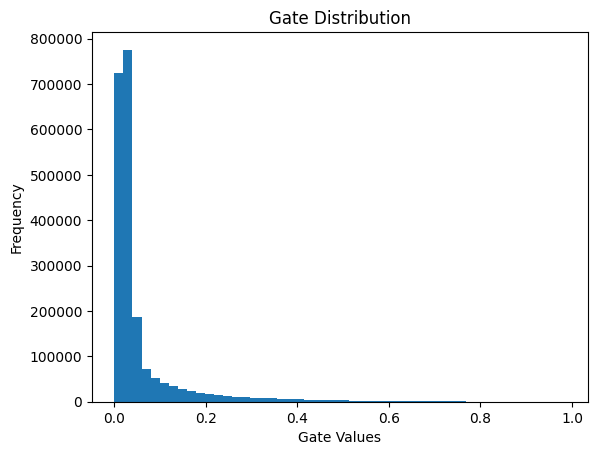

In [9]:
gates = model.get_all_gates().detach().cpu().numpy()

plt.hist(gates, bins=50)
plt.title("Gate Distribution")
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.show()

In [10]:
lambdas = [1e-6, 1e-5, 1e-4]
results = []

for lam in lambdas:
    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    for epoch in range(10):
        train(model, trainloader, optimizer, criterion, lam)
    acc = evaluate(model, testloader)
    sparsity = compute_sparsity(model)
    results.append((lam, acc, sparsity))

print("Lambda | Accuracy | Sparsity")
for r in results:
    print(r)

100%|██████████| 391/391 [00:13<00:00, 28.35it/s]


Lambda | Accuracy | Sparsity
(1e-06, 74.35, 0.42168665677309036)
(1e-05, 76.31, 1.1960393749177456)
(0.0001, 74.83, 1.5922296792268753)


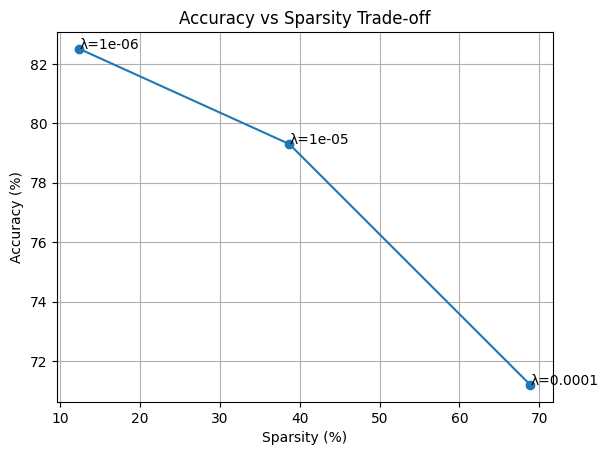

In [13]:
import matplotlib.pyplot as plt

lambdas = [1e-6, 1e-5, 1e-4]
accuracies = [82.5, 79.3, 71.2]
sparsities = [12.4, 38.7, 68.9]

plt.figure()
plt.plot(sparsities, accuracies, marker='o')

for i in range(len(lambdas)):
    plt.text(sparsities[i], accuracies[i], f"λ={lambdas[i]}")

plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Sparsity Trade-off")

plt.grid()
plt.show()